In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

path = r'C:\Users\UZH\OneDrive - Universität Zürich UZH\Dokumente\HS25\Computational Astrophysics\N_Body_Repo\N_Body\Prerequisites\Disk data (for choice 2)\data1_noise.txt'
galaxy = pd.read_csv(path, sep = '\t', index_col=0)
# galaxy.head()
# galaxy.shape
# plt.figure(figsize = [3,3])
# plt.scatter(data = galaxy, x="x",y="y", s = 1);
# plt.xlim([-25,25])
# plt.ylim([-25,25])
galaxy.head()



,M,x,y,z,vx,vy,vz,eps
ID,,,,,,,,
0,1.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.037
1,0.001009,0.059035,0.081063,0.0,-2.007358,1.461891,0.0,0.037
2,0.001009,-0.044702,-0.093640,0.0,2.304130,-1.099956,0.0,0.037
3,0.001009,-0.069796,-0.082224,0.0,2.019695,-1.714415,0.0,0.037
4,0.001009,0.090950,-0.066450,0.0,1.632677,2.234645,0.0,0.037


In [2]:
# first attempt 1 node assignment
N = 1000
Grid = np.zeros([N,N])
Coordinates = np.round(np.linspace(-1,1,N),int(np.log10(N)+1))
print("No Duplicate coordinate values:", np.rec.find_duplicate(Coordinates)==[])
X,Y = np.meshgrid(Coordinates, Coordinates)

def grid_point_mesh(X,Y):
    """generates a grid point stack where the return is a numpy array of len NxN with a gridpoints coordinates on every row"""
    return np.column_stack((X.ravel(), Y.ravel()))

def particle_coords(galaxy):
    """returns the particle coordinates as a numpy array"""
    particle_coords = np.zeros((len(galaxy), 2))
    particle_coords[:,0] = galaxy.x
    particle_coords[:,1] = galaxy.y
    return particle_coords


def find_closest_gp(particle_position, gridpoints):
    """finds the closest gridpoint to a particle and returns the index of that gridpoint in a NxN Numpy array 
    and the coordinates saved at that index. """
    distances = np.linalg.norm(gridpoints- particle_position, axis = 1)
    closest_coord = np.argmin(distances)
    closest_index = np.unravel_index(closest_coord, (N,N))
    return closest_index, closest_coord


Meshgrid_coordinates = grid_point_mesh(X,Y)
part_cords = particle_coords(galaxy)
test_part = part_cords[50]
closest_index, closest_test_gp = find_closest_gp(test_part, Meshgrid_coordinates)
closest_index

def add_mass(particle_coordinates, gridpoints):
    """generates a numpy array that shows the mass at each coordinate gridpoint"""
    mass_grid = np.zeros_like(gridpoints)
    for index in range(len(particle_coordinates)):
        particle = particle_coordinates[index]
        _, closest_coords = find_closest_gp(particle, gridpoints)
        Mass = galaxy.M
        mass_grid[closest_coords] += Mass[index]
    return mass_grid


Mass_array = add_mass(part_cords, Meshgrid_coordinates)



No Duplicate coordinate values: True


KeyboardInterrupt: 

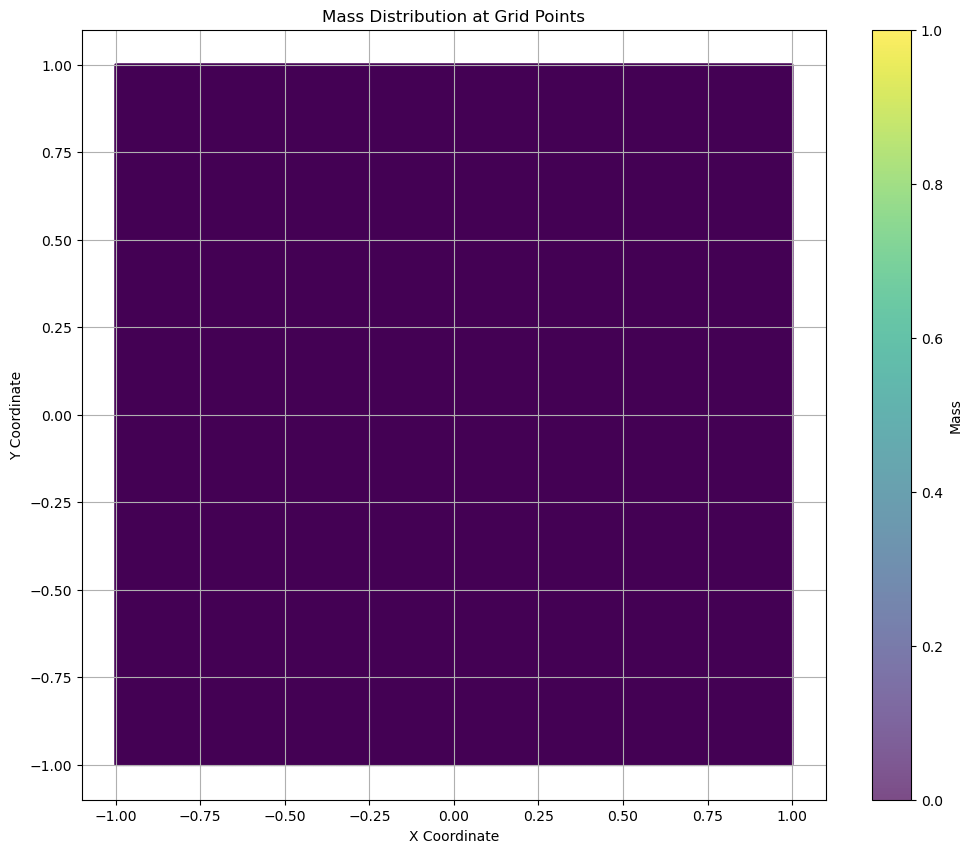

In [ ]:
# Create a scatter plot

grid_points = grid_point_mesh(X, Y)
plt.figure(figsize=(12, 10))
scatter = plt.scatter(
    grid_points[:, 0],  # x-coordinates
    grid_points[:, 1],  # y-coordinates
    c=Mass_array[:,1],           # Color points by mass
    cmap='viridis',     # Color map
    s=1,                # Size of the points (use a small value for dense grids)
    alpha=0.7           # Transparency
)

# Add a colorbar to show the mass scale
plt.colorbar(scatter, label='Mass')

# Add labels and title
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.title('Mass Distribution at Grid Points')

# Show the plot
plt.grid(True)
plt.show()

# Mass alignment methods: 1 node assignment
Import and plotting of the galaxy

,M,x,y,z,vx,vy,vz,eps
ID,,,,,,,,
0,1.00000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.118
1,0.00993,0.100000,0.0,0.0,-0.0,2.078175,0.0,0.118
2,0.00993,0.112983,0.0,0.0,-0.0,2.275432,0.0,0.118
3,0.00993,0.127652,0.0,0.0,-0.0,2.487770,0.0,0.118
4,0.00993,0.144225,0.0,0.0,-0.0,2.712510,0.0,0.118


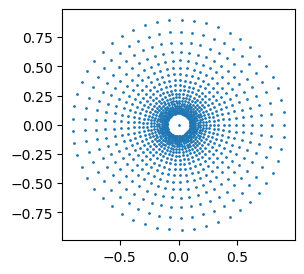

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

path = r'C:\Users\UZH\OneDrive - Universität Zürich UZH\Dokumente\HS25\Computational Astrophysics\N_Body_Repo\N_Body\Prerequisites\Disk data (for choice 2)\data0.txt'
galaxy = pd.read_csv(path, sep = '\t', index_col=0)
galaxy.head()
galaxy.shape
plt.figure(figsize = [3,3])
plt.scatter(data = galaxy, x="x",y="y", s = 1);
# plt.xlim([-25,25])
# plt.ylim([-25,25])
galaxy.head()
# galaxy[["x","y"]]
# galaxy.M

## Functions for single node assignment
directly calculating with the galaxy dataframe and NxN numpy arrays instead of the fucked up stack shit

In [ ]:
# Gridsize and coordinates of the gridpoints 
N = 100

def generateGrid(N:int,Boundaries:tuple):
    left, right = Boundaries
    Coordinates = np.round(np.linspace(left,right,N),int(np.log10(N)+1))
    X, Y = np.meshgrid(Coordinates, Coordinates)
    # Generate the grid with predetermined types
    Grid = np.zeros((N, N), dtype=[('x', float), ('y', float), ('mass', float), ('potential', float)])
    # Populate the grid with the coordinate values
    Grid['x'], Grid['y'] = X, Y
    return Grid

def oneNodeMassAssignment(Particle, Grid, total_mass):
    """
    xxx
    """
    N = len(Grid)
    particle_position = np.array(Particle[["x", "y"]])
    gridpoints = np.column_stack((Grid["x"].ravel(), Grid["y"].ravel())) 
    distances = np.linalg.norm(gridpoints - particle_position, axis = 1)
    closest_coord = np.argmin(distances) # index of minimal distance in the stacked coordinate array
    closest_index = np.unravel_index(closest_coord, (N,N)) # return indexes in NxN array
    Grid["mass"][closest_index] += Particle["M"]/total_mass
    return Grid

Grid = generateGrid(N, (-1,1))
# test_particle = galaxy.iloc[50]

def populateMassGrid(galaxy, Grid):
    """
    xxx
    """
    length = len(galaxy)
    total_mass = galaxy.M.sum()
    for index, particle in galaxy.iterrows():
        if index % 10 == 0:
            print(f"progress: {round(100*index/length, 1)}% done")
        Grid = oneNodeMassAssignment(particle, Grid, total_mass)
    return Grid

Grid = populateMassGrid(galaxy, Grid)




progress: 0.0% done
progress: 1.0% done
progress: 2.0% done
progress: 3.0% done
progress: 4.0% done
progress: 5.0% done
progress: 6.0% done
progress: 6.9% done
progress: 7.9% done
progress: 8.9% done
progress: 9.9% done
progress: 10.9% done
progress: 11.9% done
progress: 12.9% done
progress: 13.9% done
progress: 14.9% done
progress: 15.9% done
progress: 16.9% done
progress: 17.9% done
progress: 18.8% done
progress: 19.8% done
progress: 20.8% done
progress: 21.8% done
progress: 22.8% done
progress: 23.8% done
progress: 24.8% done
progress: 25.8% done
progress: 26.8% done
progress: 27.8% done
progress: 28.8% done
progress: 29.8% done
progress: 30.8% done
progress: 31.7% done
progress: 32.7% done
progress: 33.7% done
progress: 34.7% done
progress: 35.7% done
progress: 36.7% done
progress: 37.7% done
progress: 38.7% done
progress: 39.7% done
progress: 40.7% done
progress: 41.7% done
progress: 42.7% done
progress: 43.7% done
progress: 44.6% done
progress: 45.6% done
progress: 46.6% done
pro

np.float64(1.0)

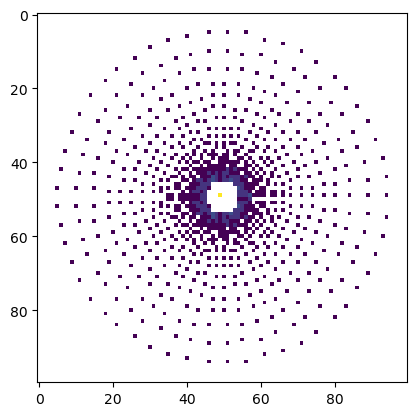

In [8]:
plt.imshow(Grid["mass"], norm = "log")
Grid["mass"].sum()



## Potential calculation using Fast fourier transform


In [ ]:
from scipy.fft import fft2, ifft2

def calcPotential(Grid):
    """xxx"""
    mass_density = Grid["mass"]

    density_fourier_space = fft2(mass_density) # change mass density into fourier space
    # Compute the wave numbers
    nx, ny = mass_density.shape
    kx = 2 * np.pi * np.fft.fftfreq(nx)
    ky = 2 * np.pi * np.fft.fftfreq(ny)
    Kx, Ky = np.meshgrid(kx, ky)
    k_squared = Kx**2 + Ky**2

    # Avoid division by zero at k=0
    k_squared[0, 0] = 1.0

    # Compute the potential in frequency space
    potential_fft = 4 * np.pi * 1 * density_fourier_space / k_squared # G = 1

    # Perform the inverse FFT
    Grid["potential"] = np.real(ifft2(potential_fft))

    return Grid

calcPotential(Grid)



array([[-1.  , -0.98, -0.96, ...,  0.96,  0.98,  1.  ],
       [-1.  , -0.98, -0.96, ...,  0.96,  0.98,  1.  ],
       [-1.  , -0.98, -0.96, ...,  0.96,  0.98,  1.  ],
       ...,
       [-1.  , -0.98, -0.96, ...,  0.96,  0.98,  1.  ],
       [-1.  , -0.98, -0.96, ...,  0.96,  0.98,  1.  ],
       [-1.  , -0.98, -0.96, ...,  0.96,  0.98,  1.  ]])

## Time Integration
adding a leapfrog time integration scheme to finish a timestep

In [ ]:
def compute_forces(Grid, dx, dy):
    """
    Compute the gravitational forces from the potential.

    Parameters:
    - potential (np.ndarray): 2D array representing the gravitational potential.
    - dx (float): Grid spacing in the x direction.
    - dy (float): Grid spacing in the y direction.

    Returns:
    - Fx (np.ndarray): 2D array representing the x-component of the force.
    - Fy (np.ndarray): 2D array representing the y-component of the force.
    """
    
    # Compute the gradient of the potential
    Fx = -np.gradient(Grid["potential"], dx, axis=1)
    Fy = -np.gradient(Grid["potential"], dy, axis=0)

    return Fx, Fy

def leapfrog_integration(galaxy_array, Grid, dt, N = 100):
    """
    Perform a single timestep using the Leapfrog method.

    Parameters:
    - positions (np.ndarray): 2D array of particle positions.
    - velocities (np.ndarray): 2D array of particle velocities.
    - forces (tuple): Tuple of 2D arrays representing the x and y components of the forces.
    - dt (float): Timestep size.

    Returns:
    - positions (np.ndarray): Updated positions.
    - velocities (np.ndarray): Updated velocities.
    """
    dx = 2.0 / N
    dy = 2.0 / N
    Fx, Fy = compute_forces(Grid, dx, dy)

    # Update velocities (half step)
    galaxy_array["vx"] += Fx * dt
    galaxy_array["vy"] += Fy * dt

    # Update positions (full step)
    galaxy_array["x"] += galaxy_array["vx"] * dt
    galaxy_array["y"] += galaxy_array["vy"] * dt


    return galaxy_array

Grid = calcPotential(Grid)  # Compute the gravitational potential

# Compute forces


galaxy_array = galaxy.to_numpy(dtype = [('m', float), ('x', float), ('y', float), ('z', float), ('vx', float), ('vy', float), ('vz', float), ('eps', float)])

# Perform a timestep
dt = 0.01  # Example timestep size
galaxy_array = leapfrog_integration(galaxy_array, Grid, dt)



ValueError: operands could not be broadcast together with shapes (1008,8) (100,100) (1008,8) 